<a href="https://www.kaggle.com/code/ameythakur20/hedge-fund-time-series-forecasting" target="_blank">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle">
</a>

# Hedge Fund - Time Series Forecasting: Sequential Prediction Framework

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

This notebook implements a sequential prediction workflow for the competition dataset. The notebook is organized as a standard modeling notebook: environment setup, data loading, exploratory analysis, causal feature engineering, rolling validation, final training, diagnostics, and submission export.

## 1. Environment & Hardware Setup

This section imports the required libraries, fixes the random seed, and sets the plotting style used throughout the notebook.

In [1]:
import gc
import os
import random
import warnings
from pathlib import Path

# Core modeling and analysis libraries
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# Shared plotting defaults for the notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reproducibility helper used across the notebook
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)
print("Environment ready. Random seed fixed to 42.")

Environment ready. Random seed fixed to 42.


## 2. Metric, Helpers, and Competition Paths

This section defines the competition metric, memory helpers, and the file discovery logic for the Kaggle input directory.

In [2]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

# Competition metric copied from the problem statement
def weighted_rmse_score(y_true, y_pred, w) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)

    denom = np.sum(w * np.square(y_true))
    if denom <= 0:
        return 0.0

    ratio = np.sum(w * np.square(y_true - y_pred)) / denom
    return float(np.sqrt(1.0 - _clip01(ratio)))

def reduce_memory_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_object_dtype(col_type):
            continue
        if pd.api.types.is_datetime64_any_dtype(col_type):
            continue

        c_min = df[col].min()
        c_max = df[col].max()

        if pd.api.types.is_integer_dtype(col_type):
            if np.iinfo(np.int8).min <= c_min <= c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif np.iinfo(np.int16).min <= c_min <= c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif np.iinfo(np.int32).min <= c_min <= c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif pd.api.types.is_float_dtype(col_type):
            if np.finfo(np.float32).min <= c_min <= c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage: {start_mem:,.1f} MB -> {end_mem:,.1f} MB")

    return df

# Central configuration used throughout the notebook
class CFG:
    seed = 42
    id_col = "id"
    target_col = "y_target"
    weight_col = "weight"
    time_col = "ts_index"
    horizon_col = "horizon"

    lag_top_k = 8
    feature_sample_size = 800_000
    cv_valid_window = 160
    cv_train_window = 1_440
    n_folds = 3

    recency_alpha = 0.55
    clip_quantiles = (0.001, 0.999)

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": 0.03,
        "n_estimators": 2500,
        "num_leaves": 255,
        "max_depth": -1,
        "min_child_samples": 80,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.10,
        "reg_lambda": 2.0,
        "random_state": seed,
        "n_jobs": -1,
        "force_col_wise": True,
        "verbosity": -1,
    }

    specialist_lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": 0.025,
        "n_estimators": 3000,
        "num_leaves": 383,
        "max_depth": -1,
        "min_child_samples": 48,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.08,
        "reg_lambda": 1.5,
        "random_state": seed,
        "n_jobs": -1,
        "force_col_wise": True,
        "verbosity": -1,
    }
# Search the Kaggle input directory instead of hard-coding a folder name
def discover_competition_files():
    input_root = Path("/kaggle/input")
    train_path = next(input_root.rglob("train.parquet"), None)
    test_path = next(input_root.rglob("test.parquet"), None)
    sample_path = next(input_root.rglob("sample_submission.csv"), None)

    if train_path is None or test_path is None:
        raise FileNotFoundError("Competition parquet files were not found under /kaggle/input.")

    return train_path, test_path, sample_path

TRAIN_PATH, TEST_PATH, SAMPLE_PATH = discover_competition_files()

print(f"Train path: {TRAIN_PATH}")
print(f"Test path : {TEST_PATH}")
print(f"Sample sub: {SAMPLE_PATH if SAMPLE_PATH else 'not provided; test ids will be used'}")





Train path: /kaggle/input/competitions/ts-forecasting/train.parquet
Test path : /kaggle/input/competitions/ts-forecasting/test.parquet
Sample sub: not provided; test ids will be used


## 3. Data Loading and First Audit

This section loads the parquet files, identifies the feature columns, and prints a small schema audit before feature work starts.

In [3]:
# Load the competition datasets
train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH) if SAMPLE_PATH else test[[CFG.id_col]].copy()

# Separate raw features from identifier columns
feature_cols = sorted([col for col in train.columns if col.startswith("feature_")])
raw_category_cols = ["code", "sub_code", "sub_category"]

# Reduce numeric memory usage before EDA and feature engineering
train = reduce_memory_usage(train)
test = reduce_memory_usage(test)

dataset_overview = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "unique_ts_index": [train[CFG.time_col].nunique(), test[CFG.time_col].nunique()],
        "min_ts_index": [int(train[CFG.time_col].min()), int(test[CFG.time_col].min())],
        "max_ts_index": [int(train[CFG.time_col].max()), int(test[CFG.time_col].max())],
        "unique_codes": [train["code"].nunique(), test["code"].nunique()],
        "unique_sub_codes": [train["sub_code"].nunique(), test["sub_code"].nunique()],
        "unique_sub_categories": [train["sub_category"].nunique(), test["sub_category"].nunique()],
    }
)
display(dataset_overview)

horizon_summary = (
    train.groupby(CFG.horizon_col)
    .agg(
        rows=(CFG.id_col, "size"),
        unique_codes=("code", "nunique"),
        target_mean=(CFG.target_col, "mean"),
        target_std=(CFG.target_col, "std"),
        weight_mean=(CFG.weight_col, "mean"),
    )
    .reset_index()
    .sort_values(CFG.horizon_col)
)
display(horizon_summary)

print(f"Feature count: {len(feature_cols)}")
display(sample_submission.head())

Memory usage: 4,913.3 MB -> 3,091.0 MB
Memory usage: 1,310.3 MB -> 827.3 MB


,split,rows,columns,unique_ts_index,min_ts_index,max_ts_index,unique_codes,unique_sub_codes,unique_sub_categories
0,train,5337414,94,3601,1,3601,23,180,5
1,test,1447107,92,775,3602,4376,23,47,5


,horizon,rows,unique_codes,target_mean,target_std,weight_mean
0,1,1394653,23,-0.082721,11.699685,16686396.0
1,3,1385816,23,-0.252409,19.361189,23664316.0
2,10,1337236,23,-0.775965,33.842064,11750303.0
3,25,1219709,23,-1.681878,52.823280,13038639.0


Feature count: 86


,id
0,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647
1,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647
2,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647
3,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647
4,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648


## 4. Exploratory Data Analysis

This section reviews the main properties of the training data: horizon balance, target distribution, missingness, time behavior, and one representative trajectory.

In [4]:
# Common EDA tables and reusable frames
eda_sample = train.sample(min(250_000, len(train)), random_state=CFG.seed).copy()

eda_overview = (
    train.groupby(CFG.horizon_col)
    .agg(
        rows=(CFG.id_col, "size"),
        target_mean=(CFG.target_col, "mean"),
        target_std=(CFG.target_col, "std"),
        weight_median=(CFG.weight_col, "median"),
    )
    .reset_index()
    .sort_values(CFG.horizon_col)
)
display(eda_overview)

target_low, target_high = eda_sample[CFG.target_col].quantile([0.01, 0.99])
target_distribution_sample = eda_sample.loc[
    eda_sample[CFG.target_col].between(target_low, target_high)
].copy()

missing_rate = (
    train[feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_rate"})
)

horizon_compare = pd.concat(
    [
        train[[CFG.horizon_col]].assign(split="train"),
        test[[CFG.horizon_col]].assign(split="test"),
    ],
    axis=0,
    ignore_index=True,
)

median_target_by_time = (
    train.groupby([CFG.time_col, CFG.horizon_col])[CFG.target_col]
    .median()
    .reset_index()
)

dense_stream = (
    train.groupby(raw_category_cols + [CFG.horizon_col], observed=True)
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
    .iloc[0]
)
dense_mask = np.logical_and.reduce(
    [
        train["code"] == dense_stream["code"],
        train["sub_code"] == dense_stream["sub_code"],
        train["sub_category"] == dense_stream["sub_category"],
        train[CFG.horizon_col] == dense_stream[CFG.horizon_col],
    ]
)
dense_trace = train.loc[dense_mask, [CFG.time_col, CFG.target_col]].sort_values(CFG.time_col)

train_time_density = (
    train.groupby(CFG.time_col)
    .size()
    .reset_index(name="rows")
    .assign(split="train")
)
test_time_density = (
    test.groupby(CFG.time_col)
    .size()
    .reset_index(name="rows")
    .assign(split="test")
)
time_density = pd.concat([train_time_density, test_time_density], axis=0, ignore_index=True)

time_bins = pd.qcut(train[CFG.time_col], q=min(12, train[CFG.time_col].nunique()), duplicates="drop")
target_heatmap = (
    train.assign(time_bin=time_bins)
    .groupby(["time_bin", CFG.horizon_col])[CFG.target_col]
    .median()
    .unstack(CFG.horizon_col)
)

variance_features = (
    train[feature_cols]
    .var()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)
correlation_sample = train[variance_features].sample(min(40_000, len(train)), random_state=CFG.seed)
correlation_matrix = correlation_sample.corr()

missing_heatmap_features = missing_rate["feature"].head(12).tolist()
missing_pattern = (
    train[missing_heatmap_features]
    .sample(min(1_000, len(train)), random_state=CFG.seed)
    .isna()
    .astype(int)
)

,horizon,rows,target_mean,target_std,weight_median
0,1,1394653,-0.082721,11.699685,2301.884766
1,3,1385816,-0.252409,19.361189,1804.246460
2,10,1337236,-0.775965,33.842064,1517.371582
3,25,1219709,-1.681878,52.823280,1318.564941


### Horizon balance

The first plot compares the number of rows in train and test for each horizon.

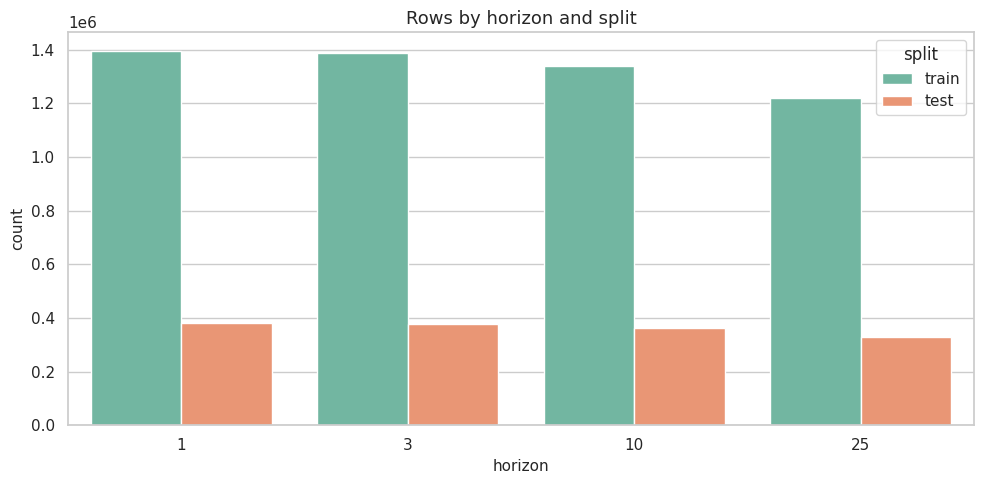

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=horizon_compare, x=CFG.horizon_col, hue="split", palette="Set2")
plt.title("Rows by horizon and split")
plt.xlabel("horizon")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Target distribution by horizon

This view trims the outer one percent on each side so the central shape is easier to read.

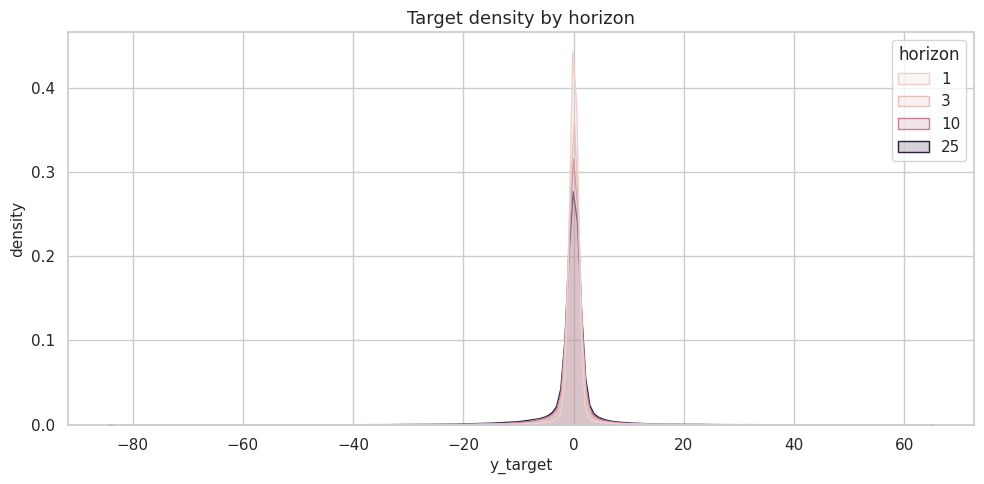

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=target_distribution_sample,
    x=CFG.target_col,
    hue=CFG.horizon_col,
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title("Target density by horizon")
plt.xlabel("y_target")
plt.ylabel("density")
plt.tight_layout()
plt.show()

### Weight distribution by horizon

The vertical axis is shown on a log scale because the weight distribution is highly skewed.

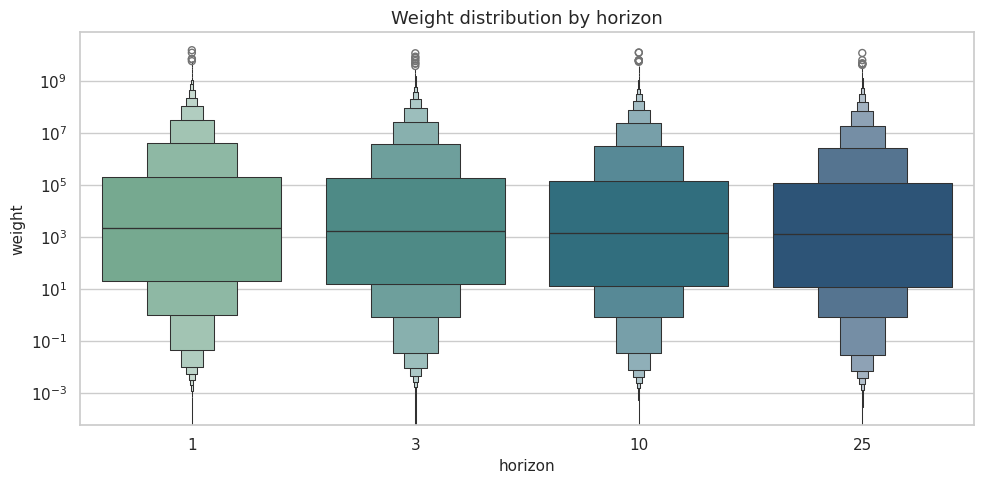

In [7]:
plt.figure(figsize=(10, 5))
sns.boxenplot(data=eda_sample, x=CFG.horizon_col, y=CFG.weight_col, palette="crest")
plt.yscale("log")
plt.title("Weight distribution by horizon")
plt.xlabel("horizon")
plt.ylabel("weight")
plt.tight_layout()
plt.show()

### Missingness by feature

This plot highlights the features with the largest missing share.

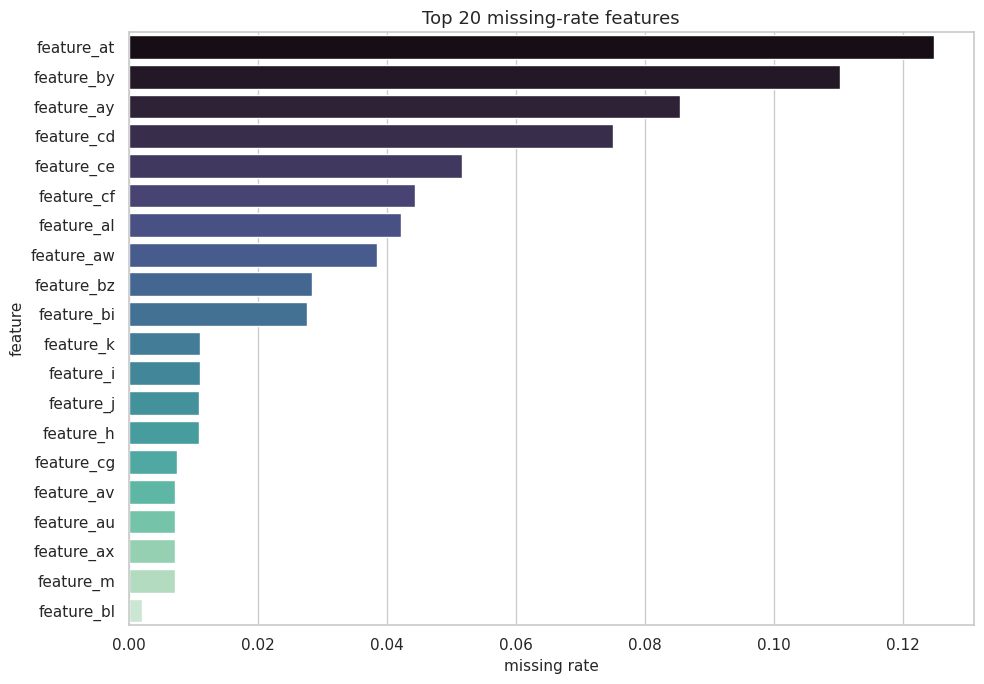

In [8]:
plt.figure(figsize=(10, 7))
sns.barplot(data=missing_rate, y="feature", x="missing_rate", palette="mako")
plt.title("Top 20 missing-rate features")
plt.xlabel("missing rate")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

### Median target over time

The median is used here because it is more stable than the mean for a noisy target.

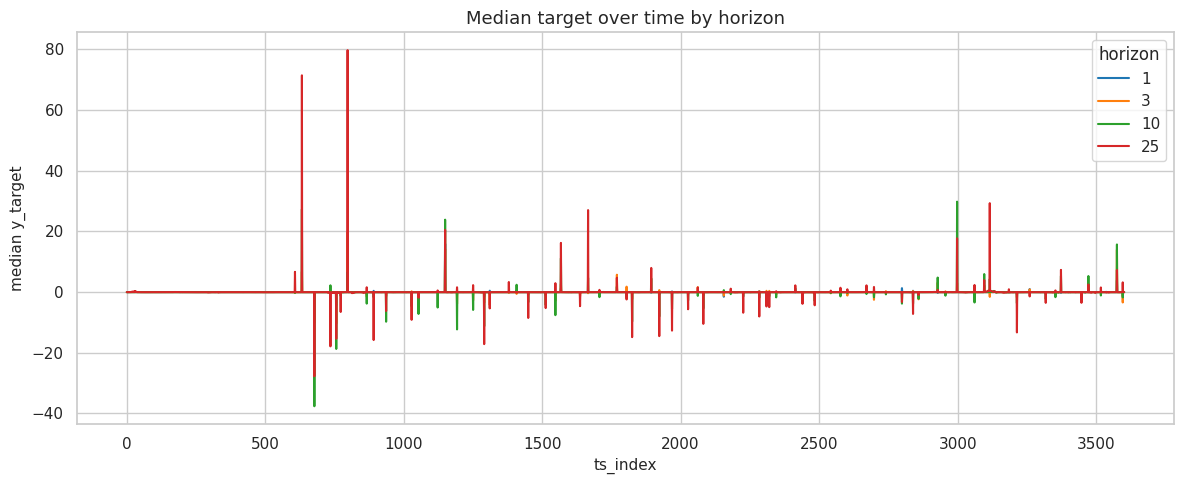

In [9]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=median_target_by_time,
    x=CFG.time_col,
    y=CFG.target_col,
    hue=CFG.horizon_col,
    palette="tab10",
)
plt.title("Median target over time by horizon")
plt.xlabel("ts_index")
plt.ylabel("median y_target")
plt.tight_layout()
plt.show()

### Example entity trajectory

This example uses one dense stream so the scale and variability over time can be viewed directly.

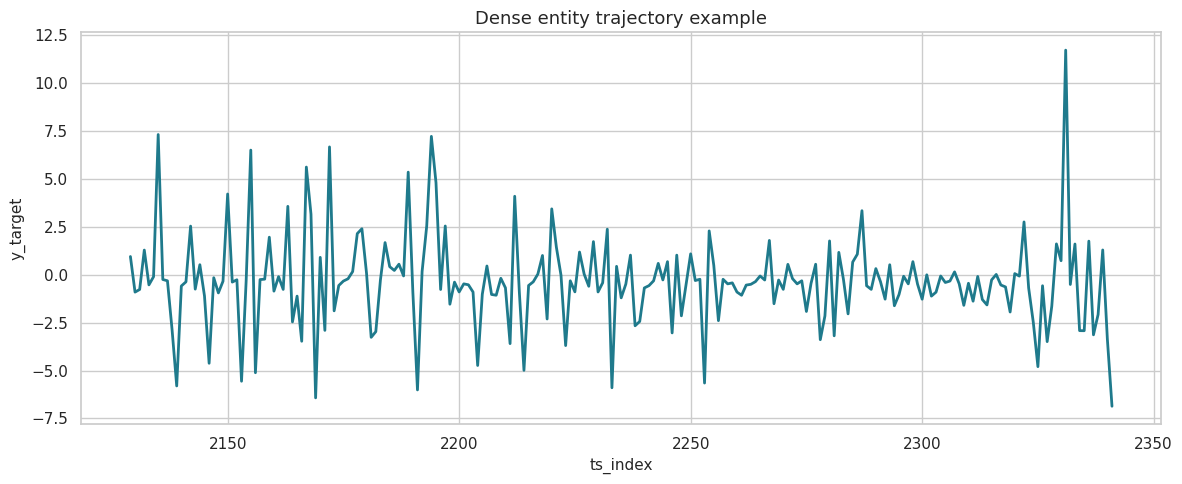

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(dense_trace[CFG.time_col], dense_trace[CFG.target_col], color="#1f7a8c", linewidth=2)
plt.title("Dense entity trajectory example")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.tight_layout()
plt.show()

### Row density over time

This plot shows how many observations appear at each timestamp in train and test.

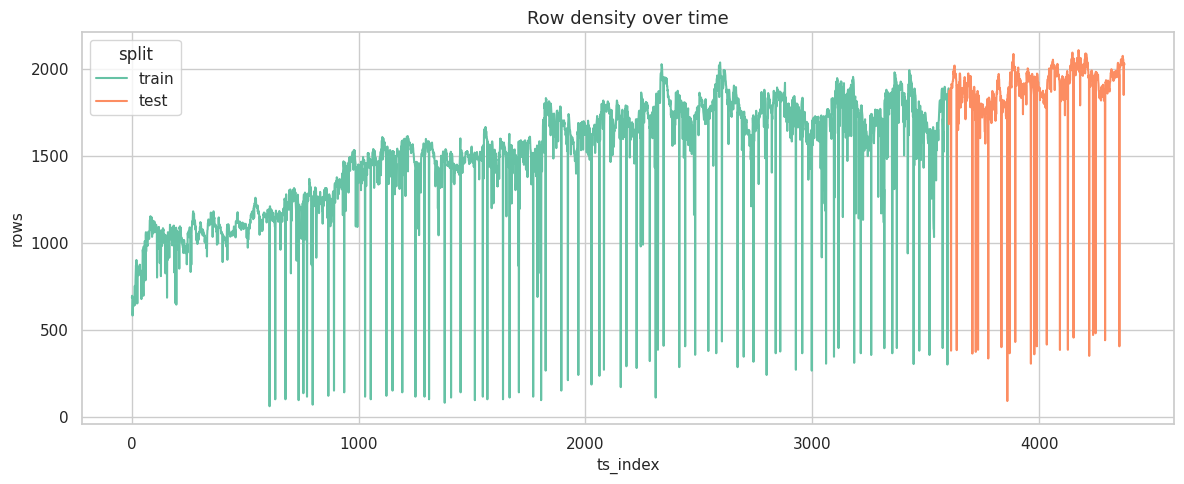

In [11]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=time_density, x=CFG.time_col, y="rows", hue="split", palette="Set2")
plt.title("Row density over time")
plt.xlabel("ts_index")
plt.ylabel("rows")
plt.tight_layout()
plt.show()

### Median target by period and horizon

Broad time buckets make the horizon-level shifts easier to compare than a raw timestamp heatmap.

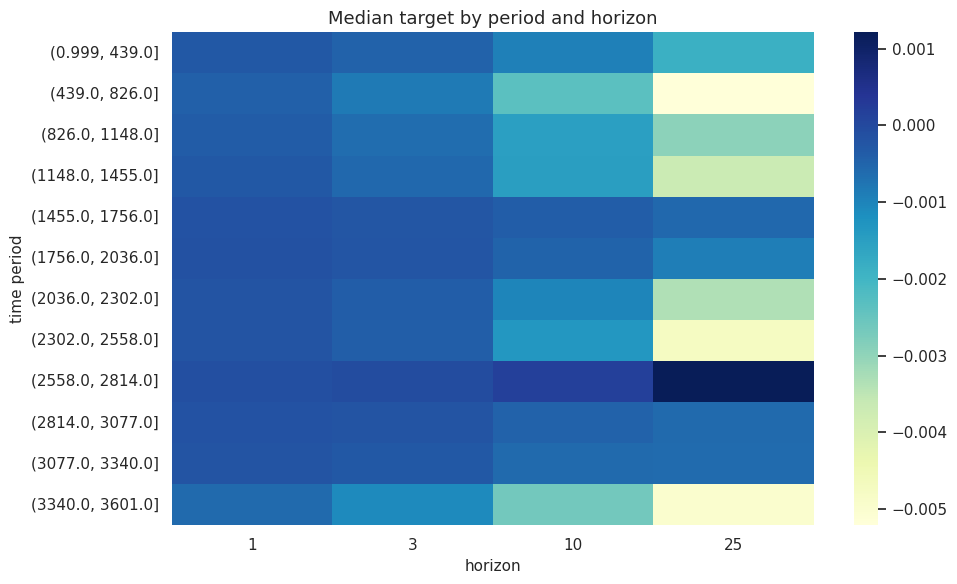

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(target_heatmap, cmap="YlGnBu")
plt.title("Median target by period and horizon")
plt.xlabel("horizon")
plt.ylabel("time period")
plt.tight_layout()
plt.show()

### Correlation view for high-variance features

The correlation matrix is limited to a small set of high-variance raw features to keep the view readable.

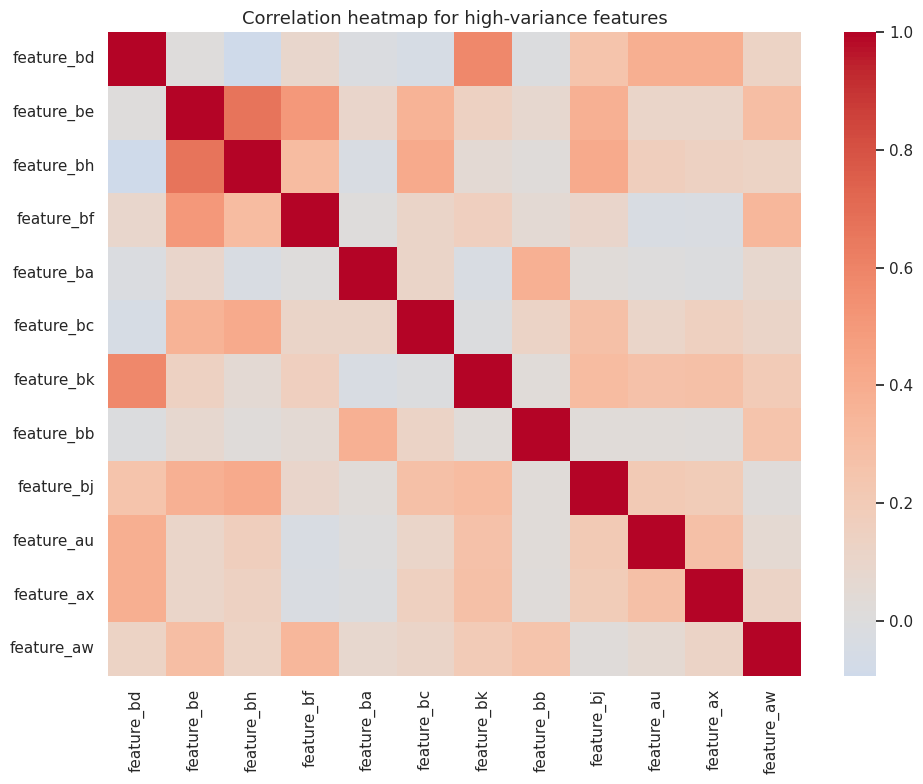

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation heatmap for high-variance features")
plt.tight_layout()
plt.show()

### Missingness pattern sample

This small binary heatmap gives a direct view of how the most incomplete features are missing together.

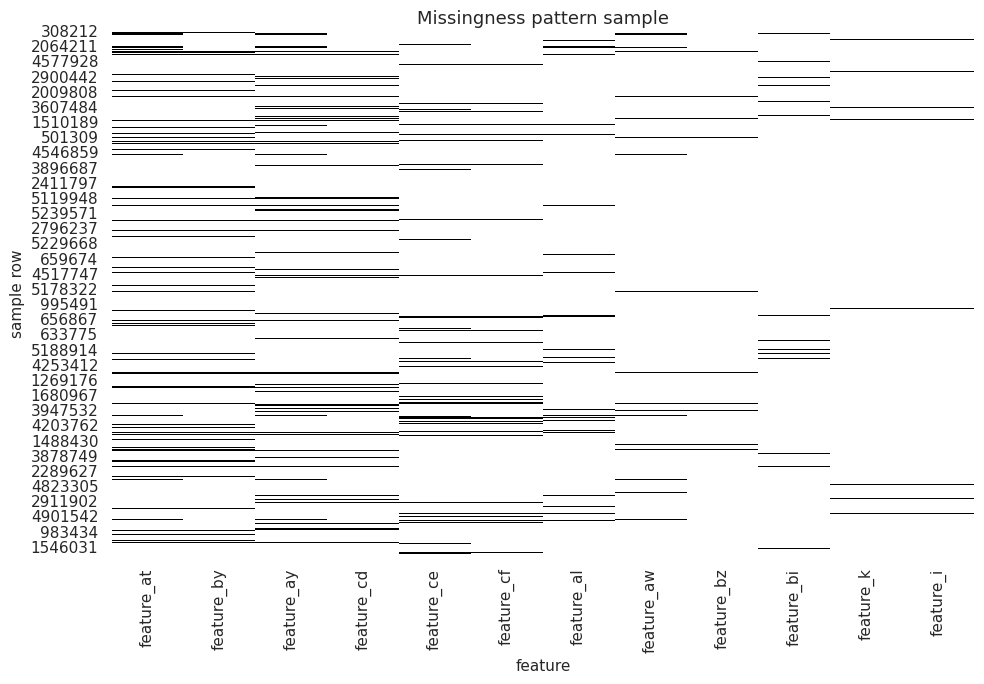

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(missing_pattern, cmap="Greys", cbar=False)
plt.title("Missingness pattern sample")
plt.xlabel("feature")
plt.ylabel("sample row")
plt.tight_layout()
plt.show()

## 5. Sequential Feature Engineering

This section prepares the model matrix. The feature block includes current-row summaries, encoded identifiers, and lag-based statistics built only from past rows within each `(code, sub_code, sub_category, horizon)` stream.

In [15]:
def weighted_abs_corr(x, y, w) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)
    if mask.sum() < 10:
        return 0.0

    x = x[mask]
    y = y[mask]
    w = w[mask]

    w_sum = w.sum()
    if w_sum <= 0:
        return 0.0

    x_mean = np.sum(w * x) / w_sum
    y_mean = np.sum(w * y) / w_sum

    x_center = x - x_mean
    y_center = y - y_mean

    cov = np.sum(w * x_center * y_center) / w_sum
    x_var = np.sum(w * np.square(x_center)) / w_sum
    y_var = np.sum(w * np.square(y_center)) / w_sum

    if x_var <= 0 or y_var <= 0:
        return 0.0

    return float(abs(cov / np.sqrt(x_var * y_var)))

def select_focus_features(train_df, feature_columns, top_k, sample_size):
    # Rank raw features with a simple weighted correlation score.
    sample_df = train_df.sort_values(CFG.time_col).tail(min(sample_size, len(train_df))).copy()

    scores = []
    y = sample_df[CFG.target_col].to_numpy()
    w = sample_df[CFG.weight_col].to_numpy()

    for col in feature_columns:
        scores.append(
            {
                "feature": col,
                "weighted_abs_corr": weighted_abs_corr(sample_df[col].to_numpy(), y, w),
            }
        )

    score_df = pd.DataFrame(scores).sort_values("weighted_abs_corr", ascending=False).reset_index(drop=True)
    selected = score_df.head(top_k)["feature"].tolist()
    return score_df, selected

def encode_categories(train_df, test_df, cols):
    # Encode each identifier once so the same code is used in train and test.
    encoded_cols = []

    for col in cols:
        train_values = train_df[col].astype(str)
        test_values = test_df[col].astype(str)

        categories = pd.Index(train_values.unique()).union(pd.Index(test_values.unique()))
        mapping = pd.Series(np.arange(len(categories), dtype=np.int32), index=categories)

        encoded_col = f"{col}_id"
        train_df[encoded_col] = train_values.map(mapping).astype(np.int32)
        test_df[encoded_col] = test_values.map(mapping).astype(np.int32)

        freq_map = train_df[encoded_col].value_counts().to_dict()
        train_df[f"{col}_freq"] = train_df[encoded_col].map(freq_map).astype(np.float32)
        test_df[f"{col}_freq"] = test_df[encoded_col].map(freq_map).fillna(0).astype(np.float32)

        encoded_cols.append(encoded_col)

    return train_df, test_df, encoded_cols

def add_snapshot_features(df, feature_columns, ts_min, ts_max):
    # Row summaries describe the current feature state at each timestamp.
    feature_block = df[feature_columns]

    df["feature_missing_count"] = feature_block.isna().sum(axis=1).astype(np.int16)
    df["feature_row_mean"] = feature_block.mean(axis=1).astype(np.float32)
    df["feature_row_std"] = feature_block.std(axis=1).fillna(0).astype(np.float32)
    df["feature_row_min"] = feature_block.min(axis=1).astype(np.float32)
    df["feature_row_max"] = feature_block.max(axis=1).astype(np.float32)
    df["feature_row_abs_mean"] = feature_block.abs().mean(axis=1).astype(np.float32)

    df["ts_index_scaled"] = ((df[CFG.time_col] - ts_min) / max(ts_max - ts_min, 1)).astype(np.float32)

    return df

def build_causal_feature_frame(train_df, test_df, key_cols, lag_cols):
    # Build lag features on the concatenated train+test panel.
    # Sorting by key and time keeps every lag strictly backward-looking.
    keep_cols = key_cols + [CFG.time_col] + lag_cols

    train_small = train_df[keep_cols].copy()
    train_small["_dataset"] = 0
    train_small["_row_id"] = np.arange(len(train_small), dtype=np.int32)

    test_small = test_df[keep_cols].copy()
    test_small["_dataset"] = 1
    test_small["_row_id"] = np.arange(len(test_small), dtype=np.int32)

    combined = pd.concat([train_small, test_small], axis=0, ignore_index=True)
    combined = combined.sort_values(key_cols + [CFG.time_col, "_dataset", "_row_id"], kind="mergesort").reset_index(drop=True)

    grouped = combined.groupby(key_cols, sort=False)
    combined["entity_obs"] = grouped.cumcount().astype(np.int32)
    combined["time_gap_1"] = (combined[CFG.time_col] - grouped[CFG.time_col].shift(1)).fillna(-1).astype(np.float32)

    broader = combined.groupby(["sub_category_id", CFG.horizon_col], sort=False)
    combined["subcat_horizon_obs"] = broader.cumcount().astype(np.int32)

    seq_cols = ["entity_obs", "time_gap_1", "subcat_horizon_obs"]
    level_ids = list(range(len(key_cols)))

    for col in lag_cols:
        lag1 = grouped[col].shift(1)
        lag2 = grouped[col].shift(2)

        combined[f"{col}_lag1"] = lag1.astype(np.float32)
        combined[f"{col}_lag2"] = lag2.astype(np.float32)
        combined[f"{col}_diff1"] = (combined[col] - lag1).astype(np.float32)

        rolling_source = pd.concat([combined[key_cols], lag1.rename("lag1_value")], axis=1)
        combined[f"{col}_roll3_mean"] = (
            rolling_source.groupby(key_cols, sort=False)["lag1_value"]
            .rolling(window=3, min_periods=1)
            .mean()
            .reset_index(level=level_ids, drop=True)
            .astype(np.float32)
        )

        seq_cols.extend(
            [
                f"{col}_lag1",
                f"{col}_lag2",
                f"{col}_diff1",
                f"{col}_roll3_mean",
            ]
        )

    train_seq = (
        combined.loc[combined["_dataset"] == 0, ["_row_id"] + seq_cols]
        .sort_values("_row_id")
        .drop(columns="_row_id")
        .reset_index(drop=True)
        .fillna(0)
    )
    test_seq = (
        combined.loc[combined["_dataset"] == 1, ["_row_id"] + seq_cols]
        .sort_values("_row_id")
        .drop(columns="_row_id")
        .reset_index(drop=True)
        .fillna(0)
    )

    return train_seq, test_seq, seq_cols

### Apply the feature pipeline

The helper functions above are applied here in sequence: feature ranking, identifier encoding, snapshot features, sequential lag features, and the final model matrix assembly.

In [16]:
# Select a compact raw feature subset for the lag block.
focus_feature_scores, focus_features = select_focus_features(
    train_df=train,
    feature_columns=feature_cols,
    top_k=CFG.lag_top_k,
    sample_size=CFG.feature_sample_size,
)
display(focus_feature_scores.head(15))

# Encode identifiers and build static row summaries.
train, test, encoded_category_cols = encode_categories(train, test, raw_category_cols)
reference_ts_min = train[CFG.time_col].min()
reference_ts_max = train[CFG.time_col].max()
train = add_snapshot_features(train, feature_cols, ts_min=reference_ts_min, ts_max=reference_ts_max)
test = add_snapshot_features(test, feature_cols, ts_min=reference_ts_min, ts_max=reference_ts_max)

# Add lag-based features from the sequential panel.
sequential_key_cols = encoded_category_cols + [CFG.horizon_col]
train_seq, test_seq, sequential_feature_cols = build_causal_feature_frame(
    train_df=train,
    test_df=test,
    key_cols=sequential_key_cols,
    lag_cols=focus_features,
)

for col in sequential_feature_cols:
    train[col] = train_seq[col].astype(np.float32)
    test[col] = test_seq[col].astype(np.float32)

# Slightly upweight later training rows to reflect temporal drift.
train["recency_weight"] = (1.0 + CFG.recency_alpha * train["ts_index_scaled"]).astype(np.float32)
train["fit_weight"] = (train[CFG.weight_col] * train["recency_weight"]).astype(np.float32)

train = train.drop(columns=raw_category_cols)
test = test.drop(columns=raw_category_cols)

base_feature_cols = feature_cols + [
    "feature_missing_count",
    "feature_row_mean",
    "feature_row_std",
    "feature_row_min",
    "feature_row_max",
    "feature_row_abs_mean",
    "ts_index_scaled",
] + [f"{col}_freq" for col in raw_category_cols] + encoded_category_cols + [CFG.horizon_col]

model_feature_cols = base_feature_cols + sequential_feature_cols
categorical_feature_cols = encoded_category_cols + [CFG.horizon_col]

assert CFG.target_col not in model_feature_cols
assert CFG.weight_col not in model_feature_cols
assert CFG.id_col not in model_feature_cols

print(f"Selected lag features: {focus_features}")
print(f"Final feature count : {len(model_feature_cols)}")
print(f"Train shape after FE: {train.shape}")
print(f"Test shape after FE : {test.shape}")

gc.collect()

,feature,weighted_abs_corr
0,feature_bn,0.058235
1,feature_u,0.054969
2,feature_ca,0.042843
3,feature_am,0.037457
4,feature_cd,0.035189
5,feature_bo,0.032734
6,feature_v,0.030561
7,feature_an,0.029523
8,feature_ap,0.028662
9,feature_bm,0.027988


Selected lag features: ['feature_bn', 'feature_u', 'feature_ca', 'feature_am', 'feature_cd', 'feature_bo', 'feature_v', 'feature_an']
Final feature count : 135
Train shape after FE: (5337414, 141)
Test shape after FE : (1447107, 137)


14034

## 6. Feature Drift Check

This section compares a small set of selected raw features between recent training rows and the test set.

In [17]:
drift_features = focus_features[: min(4, len(focus_features))]
recent_cutoff = train[CFG.time_col].quantile(0.90)

drift_train = train.loc[train[CFG.time_col] >= recent_cutoff, drift_features].copy()
drift_train["split"] = "recent_train"

drift_test = test[drift_features].copy()
drift_test["split"] = "test"

drift_frame = pd.concat([drift_train, drift_test], axis=0, ignore_index=True)
if len(drift_frame) > 160_000:
    drift_frame = drift_frame.sample(160_000, random_state=CFG.seed)

drift_frame = drift_frame.melt(id_vars="split", var_name="feature", value_name="value")

### Drift view 1

Recent-train and test distributions for the first selected feature.

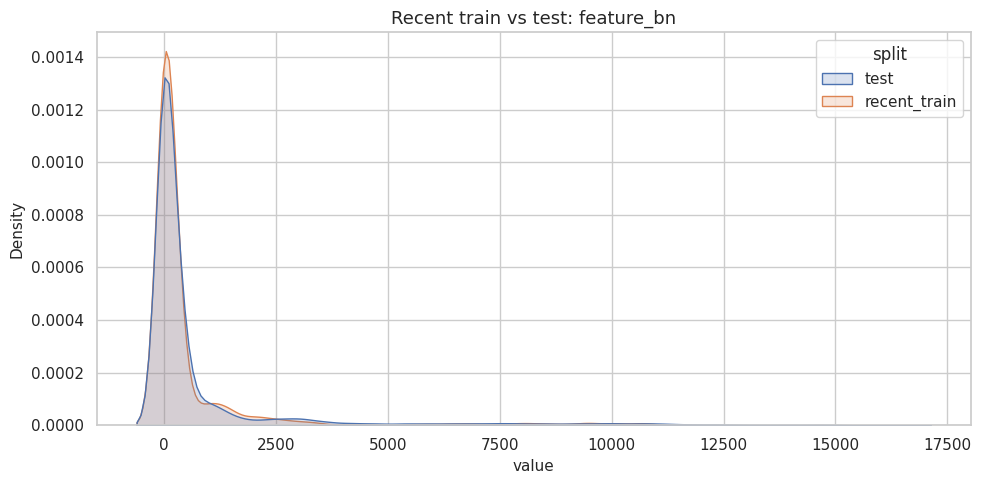

In [18]:
drift_feature_name = drift_features[0]
block = drift_frame.loc[drift_frame["feature"] == drift_feature_name]

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=block,
    x="value",
    hue="split",
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title(f"Recent train vs test: {drift_feature_name}")
plt.tight_layout()
plt.show()

### Drift view 2

Recent-train and test distributions for the second selected feature.

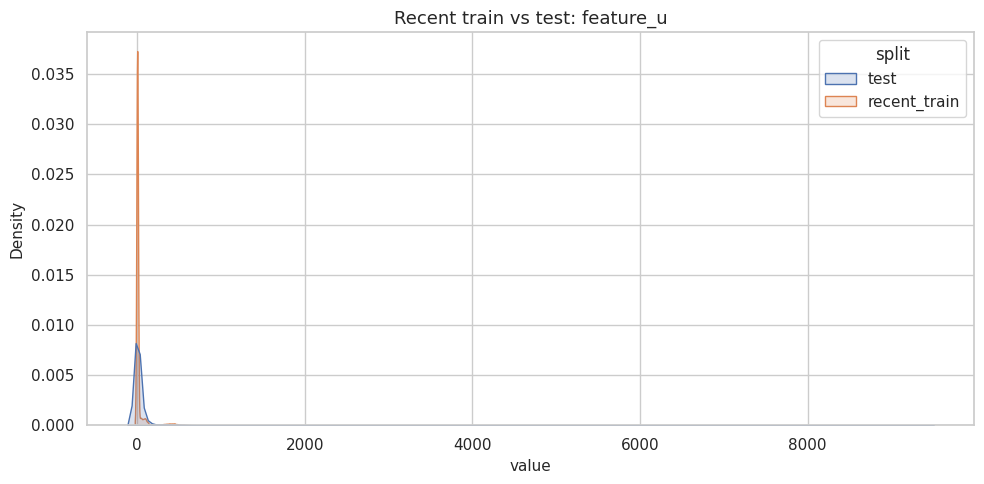

In [19]:
drift_feature_name = drift_features[1]
block = drift_frame.loc[drift_frame["feature"] == drift_feature_name]

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=block,
    x="value",
    hue="split",
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title(f"Recent train vs test: {drift_feature_name}")
plt.tight_layout()
plt.show()

### Drift view 3

Recent-train and test distributions for the third selected feature.

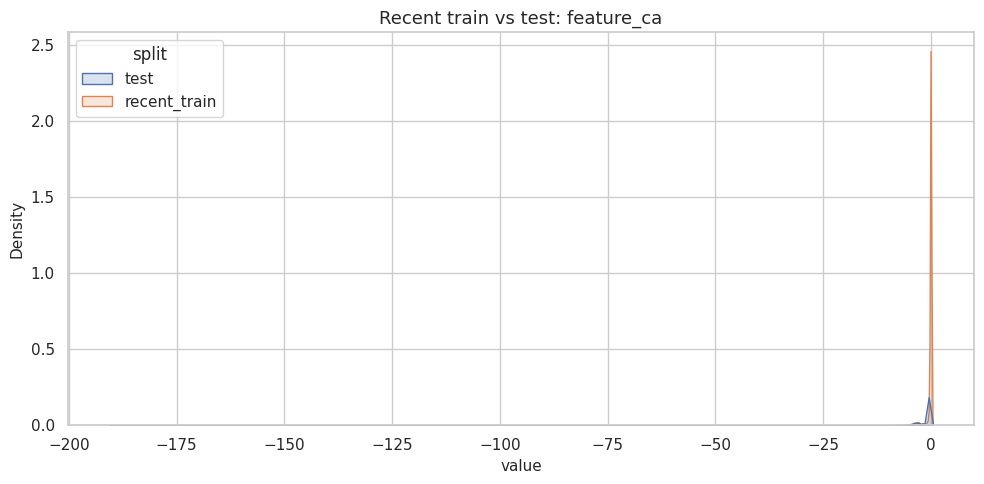

In [20]:
drift_feature_name = drift_features[2]
block = drift_frame.loc[drift_frame["feature"] == drift_feature_name]

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=block,
    x="value",
    hue="split",
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title(f"Recent train vs test: {drift_feature_name}")
plt.tight_layout()
plt.show()

### Drift view 4

Recent-train and test distributions for the fourth selected feature.

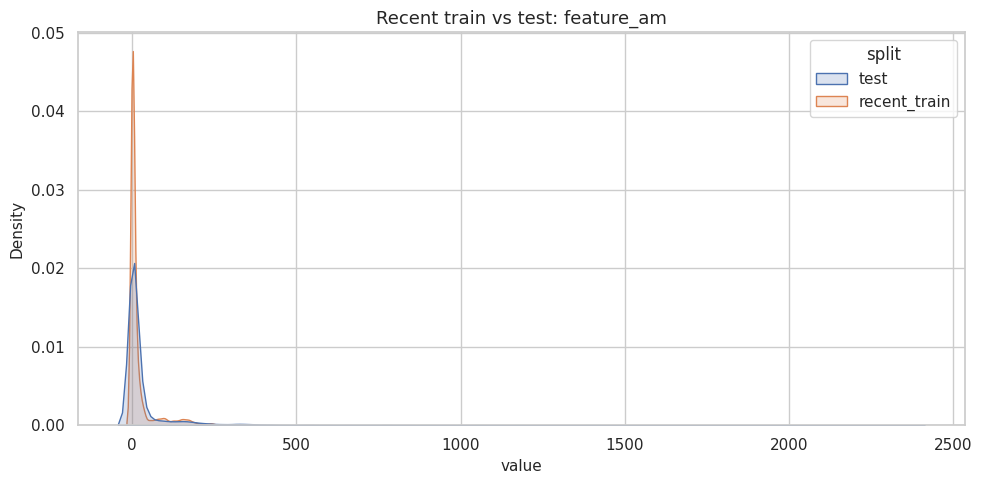

In [21]:
drift_feature_name = drift_features[3]
block = drift_frame.loc[drift_frame["feature"] == drift_feature_name]

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=block,
    x="value",
    hue="split",
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title(f"Recent train vs test: {drift_feature_name}")
plt.tight_layout()
plt.show()

## 7. Rolling Validation and Blend Search

This section uses rolling time splits for offline evaluation. The same weighted metric is used for fold scoring and for the blend search.

In [22]:
def make_time_folds(train_df, n_folds, valid_window, train_window):
    # Create rolling folds with train windows strictly before validation windows.
    unique_times = np.sort(train_df[CFG.time_col].unique())

    valid_window = int(min(valid_window, max(64, len(unique_times) // 8)))
    train_window = int(min(train_window, max(valid_window, len(unique_times) - valid_window)))

    if len(unique_times) <= valid_window + 64:
        raise ValueError("Not enough unique timestamps for the configured validation window.")

    fold_starts = [len(unique_times) - valid_window * i for i in range(n_folds, 0, -1)]
    folds = []

    for fold_id, start_pos in enumerate(fold_starts, start=1):
        valid_start_pos = max(0, start_pos)
        valid_end_pos = min(len(unique_times), valid_start_pos + valid_window)
        train_start_pos = max(0, valid_start_pos - train_window)

        train_times = unique_times[train_start_pos:valid_start_pos]
        valid_times = unique_times[valid_start_pos:valid_end_pos]

        if len(train_times) == 0 or len(valid_times) == 0:
            continue

        train_mask = train_df[CFG.time_col].isin(train_times)
        valid_mask = train_df[CFG.time_col].isin(valid_times)

        folds.append((fold_id, train_mask, valid_mask, int(valid_times[0]), int(valid_times[-1])))

    return folds

def fit_lgbm(train_part, valid_part, feature_columns, categorical_columns, params):
    # Fit one LightGBM model with weighted early stopping.
    model = lgb.LGBMRegressor(**params)
    model.fit(
        train_part[feature_columns],
        train_part[CFG.target_col],
        sample_weight=train_part["fit_weight"],
        eval_set=[(valid_part[feature_columns], valid_part[CFG.target_col])],
        eval_sample_weight=[valid_part[CFG.weight_col]],
        categorical_feature=[col for col in categorical_columns if col in feature_columns],
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=250),
        ],
    )
    return model

def score_by_horizon(frame, pred_col):
    rows = []
    for horizon_value, block in frame.groupby(CFG.horizon_col):
        rows.append(
            {
                "horizon": horizon_value,
                "rows": len(block),
                "score": weighted_rmse_score(
                    y_true=block[CFG.target_col].to_numpy(),
                    y_pred=block[pred_col].to_numpy(),
                    w=block[CFG.weight_col].to_numpy(),
                ),
            }
        )
    return pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)
def search_horizon_blend_weights(oof_df, blend_grid):
    rows = []

    for horizon_value, block in oof_df.groupby(CFG.horizon_col):
        best_row = None

        for alpha in blend_grid:
            blended = alpha * block["pred_global"].to_numpy() + (1.0 - alpha) * block["pred_specialist"].to_numpy()
            score = weighted_rmse_score(block[CFG.target_col], blended, block[CFG.weight_col])

            row = {
                "horizon": horizon_value,
                "global_weight": float(alpha),
                "specialist_weight": float(1.0 - alpha),
                "score": float(score),
            }

            if best_row is None or row["score"] > best_row["score"]:
                best_row = row

        rows.append(best_row)

    return pd.DataFrame(rows).sort_values("horizon").reset_index(drop=True)


### Run the rolling validation

The validation loop fits the global and specialist models on rolling time splits, evaluates both shared and horizon-level blend weights, and keeps the strongest blend for later use.


Prepared 3 rolling validation folds.

Fold 1: train rows=2,412,719, valid rows=271,604, window=3122 -> 3281

Fold 2: train rows=2,442,823, valid rows=277,169, window=3282 -> 3441

Fold 3: train rows=2,460,001, valid rows=263,884, window=3442 -> 3601


,fold,valid_start,valid_end,global_score,specialist_score
0,1,3122,3281,0.086340,0.000000
1,2,3282,3441,0.095143,0.000000
2,3,3442,3601,0.111727,0.063307


,global_weight,specialist_weight,score
0,0.80,0.20,0.096782
1,0.75,0.25,0.095609
2,0.70,0.30,0.094025
3,0.65,0.35,0.092008
4,0.60,0.40,0.089530


,horizon,global_weight,specialist_weight,score
0,1,0.35,0.65,0.019130
1,3,0.80,0.20,0.049938
2,10,0.80,0.20,0.070496
3,25,0.80,0.20,0.123725


,horizon,rows,score
0,1,213169,0.019130
1,3,211547,0.049938
2,10,202980,0.070496
3,25,184961,0.123725


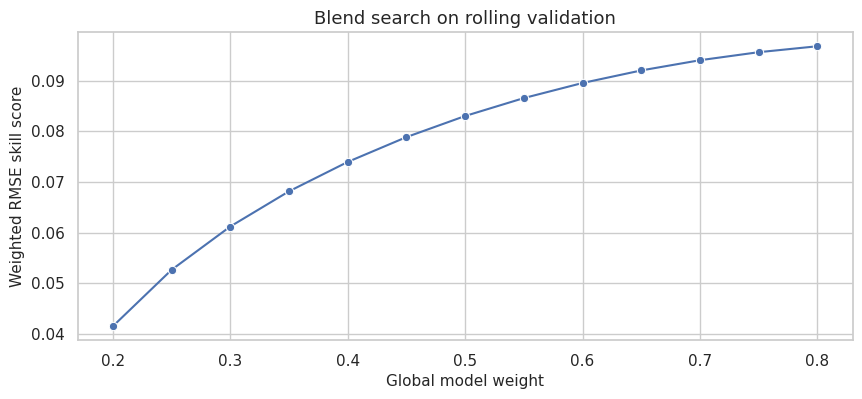

Best global blend: global=0.80, specialist=0.20
OOF global blend score : 0.096782
OOF horizon blend score: 0.097429
Selected blend mode    : horizon


In [23]:
# Prepare the rolling validation schedule.
folds = make_time_folds(
    train_df=train,
    n_folds=CFG.n_folds,
    valid_window=CFG.cv_valid_window,
    train_window=CFG.cv_train_window,
)
print(f"Prepared {len(folds)} rolling validation folds.")

oof_parts = []
fold_metrics = []
global_best_iterations = []
specialist_best_iterations = []

for fold_id, train_mask, valid_mask, valid_start, valid_end in folds:
    train_part = train.loc[train_mask].copy()
    valid_part = train.loc[valid_mask].copy()

    print(
        f"\nFold {fold_id}: "
        f"train rows={len(train_part):,}, "
        f"valid rows={len(valid_part):,}, "
        f"window={valid_start} -> {valid_end}"
    )

    # Fit one model on all horizons.
    global_model = fit_lgbm(
        train_part=train_part,
        valid_part=valid_part,
        feature_columns=model_feature_cols,
        categorical_columns=categorical_feature_cols,
        params=CFG.lgb_params.copy(),
    )
    global_pred = global_model.predict(valid_part[model_feature_cols], num_iteration=global_model.best_iteration_)
    global_best_iterations.append(int(global_model.best_iteration_ or CFG.lgb_params["n_estimators"]))

    specialist_pred = np.zeros(len(valid_part), dtype=np.float32)
    horizon_iterations = []

    # Fit one specialist model per horizon inside the same fold.
    for horizon_value in sorted(valid_part[CFG.horizon_col].unique()):
        train_h = train_part.loc[train_part[CFG.horizon_col] == horizon_value]
        valid_h_mask = valid_part[CFG.horizon_col] == horizon_value
        valid_h = valid_part.loc[valid_h_mask]

        if train_h.empty or valid_h.empty:
            specialist_pred[valid_h_mask.to_numpy()] = global_pred[valid_h_mask.to_numpy()]
            continue

        specialist_model = fit_lgbm(
            train_part=train_h,
            valid_part=valid_h,
            feature_columns=model_feature_cols,
            categorical_columns=categorical_feature_cols,
            params=CFG.specialist_lgb_params.copy(),
        )
        specialist_pred[valid_h_mask.to_numpy()] = specialist_model.predict(
            valid_h[model_feature_cols],
            num_iteration=specialist_model.best_iteration_,
        )
        horizon_iterations.append(int(specialist_model.best_iteration_ or CFG.specialist_lgb_params["n_estimators"]))
        gc.collect()

    fold_frame = valid_part[[CFG.id_col, CFG.horizon_col, CFG.target_col, CFG.weight_col]].copy()
    fold_frame["pred_global"] = global_pred
    fold_frame["pred_specialist"] = specialist_pred
    oof_parts.append(fold_frame)

    fold_metrics.append(
        {
            "fold": fold_id,
            "valid_start": valid_start,
            "valid_end": valid_end,
            "global_score": weighted_rmse_score(
                valid_part[CFG.target_col],
                global_pred,
                valid_part[CFG.weight_col],
            ),
            "specialist_score": weighted_rmse_score(
                valid_part[CFG.target_col],
                specialist_pred,
                valid_part[CFG.weight_col],
            ),
        }
    )

    specialist_best_iterations.extend(horizon_iterations)
    gc.collect()

metrics_df = pd.DataFrame(fold_metrics)
display(metrics_df)

oof_df = pd.concat(oof_parts, axis=0, ignore_index=True)

# Search a small grid for the global/specialist blend.
blend_grid = np.linspace(0.20, 0.80, 13)
blend_scores = []

for alpha in blend_grid:
    blended = alpha * oof_df["pred_global"].to_numpy() + (1.0 - alpha) * oof_df["pred_specialist"].to_numpy()
    blend_scores.append(
        {
            "global_weight": alpha,
            "specialist_weight": 1.0 - alpha,
            "score": weighted_rmse_score(oof_df[CFG.target_col], blended, oof_df[CFG.weight_col]),
        }
    )

blend_scores_df = pd.DataFrame(blend_scores).sort_values("score", ascending=False).reset_index(drop=True)
display(blend_scores_df.head())

best_global_weight = float(blend_scores_df.loc[0, "global_weight"])
best_specialist_weight = float(blend_scores_df.loc[0, "specialist_weight"])

# Also select one blend weight per horizon from the same OOF predictions.
horizon_blend_df = search_horizon_blend_weights(oof_df, blend_grid)
display(horizon_blend_df)

horizon_weight_map = horizon_blend_df.set_index("horizon")["global_weight"].to_dict()
oof_df["horizon_global_weight"] = oof_df[CFG.horizon_col].map(horizon_weight_map).astype(np.float32)
oof_df["horizon_specialist_weight"] = (1.0 - oof_df["horizon_global_weight"]).astype(np.float32)

oof_df["pred_blend"] = (
    best_global_weight * oof_df["pred_global"] +
    best_specialist_weight * oof_df["pred_specialist"]
)

oof_df["pred_horizon_blend"] = (
    oof_df["horizon_global_weight"] * oof_df["pred_global"] +
    oof_df["horizon_specialist_weight"] * oof_df["pred_specialist"]
)

global_blend_score = weighted_rmse_score(oof_df[CFG.target_col], oof_df["pred_blend"], oof_df[CFG.weight_col])
horizon_blend_score = weighted_rmse_score(oof_df[CFG.target_col], oof_df["pred_horizon_blend"], oof_df[CFG.weight_col])

blend_mode = "global"
selected_pred_col = "pred_blend"
if horizon_blend_score > global_blend_score:
    blend_mode = "horizon"
    selected_pred_col = "pred_horizon_blend"

per_horizon_scores = score_by_horizon(oof_df, selected_pred_col)
display(per_horizon_scores)

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=blend_scores_df.sort_values("global_weight"),
    x="global_weight",
    y="score",
    marker="o",
)
plt.title("Blend search on rolling validation")
plt.xlabel("Global model weight")
plt.ylabel("Weighted RMSE skill score")
plt.show()

print(f"Best global blend: global={best_global_weight:.2f}, specialist={best_specialist_weight:.2f}")
print(f"OOF global blend score : {global_blend_score:.6f}")
print(f"OOF horizon blend score: {horizon_blend_score:.6f}")
print(f"Selected blend mode    : {blend_mode}")



## 8. Final Training and Submission

This section fits the selected model families on the full training data, applies the blend rule chosen from rolling validation, clips predictions with train-derived horizon limits, and exports the final submission file.


In [24]:
# Reuse the fold-level best iteration counts for the final fit.
global_rounds = int(np.mean(global_best_iterations)) if global_best_iterations else CFG.lgb_params["n_estimators"]
specialist_rounds = int(np.mean(specialist_best_iterations)) if specialist_best_iterations else CFG.specialist_lgb_params["n_estimators"]

global_final_params = CFG.lgb_params.copy()
global_final_params["n_estimators"] = max(500, global_rounds)

specialist_final_params = CFG.specialist_lgb_params.copy()
specialist_final_params["n_estimators"] = max(400, specialist_rounds)

# Fit the global model on the full training set.
global_final_model = lgb.LGBMRegressor(**global_final_params)
global_final_model.fit(
    train[model_feature_cols],
    train[CFG.target_col],
    sample_weight=train["fit_weight"],
    categorical_feature=[col for col in categorical_feature_cols if col in model_feature_cols],
)
global_test_pred = global_final_model.predict(test[model_feature_cols])

specialist_test_pred = np.zeros(len(test), dtype=np.float32)
specialist_models = {}

# Fit a specialist model for each horizon that appears in test.
for horizon_value in sorted(test[CFG.horizon_col].unique()):
    train_h = train.loc[train[CFG.horizon_col] == horizon_value]
    test_h_mask = test[CFG.horizon_col] == horizon_value

    if train_h.empty:
        specialist_test_pred[test_h_mask.to_numpy()] = global_test_pred[test_h_mask.to_numpy()]
        continue

    specialist_model = lgb.LGBMRegressor(**specialist_final_params)
    specialist_model.fit(
        train_h[model_feature_cols],
        train_h[CFG.target_col],
        sample_weight=train_h["fit_weight"],
        categorical_feature=[col for col in categorical_feature_cols if col in model_feature_cols],
    )
    specialist_test_pred[test_h_mask.to_numpy()] = specialist_model.predict(test.loc[test_h_mask, model_feature_cols])
    specialist_models[horizon_value] = specialist_model
    gc.collect()

if blend_mode == "horizon":
    test_global_weight = test[CFG.horizon_col].map(horizon_weight_map).fillna(best_global_weight).to_numpy(dtype=np.float32)
    test_specialist_weight = (1.0 - test_global_weight).astype(np.float32)
    final_pred = (
        test_global_weight * global_test_pred +
        test_specialist_weight * specialist_test_pred
    ).astype(np.float32)
else:
    final_pred = (
        best_global_weight * global_test_pred +
        best_specialist_weight * specialist_test_pred
    ).astype(np.float32)

# Use train-only target quantiles to clip extreme forecasts.
clip_table = train.groupby(CFG.horizon_col)[CFG.target_col].quantile(list(CFG.clip_quantiles)).unstack()
clip_table.columns = ["lower", "upper"]

for horizon_value in sorted(test[CFG.horizon_col].unique()):
    if horizon_value not in clip_table.index:
        continue

    mask = test[CFG.horizon_col] == horizon_value
    lower = float(clip_table.loc[horizon_value, "lower"])
    upper = float(clip_table.loc[horizon_value, "upper"])
    final_pred[mask.to_numpy()] = np.clip(final_pred[mask.to_numpy()], lower, upper)

submission = pd.DataFrame(
    {
        CFG.id_col: test[CFG.id_col].values,
        "prediction": final_pred.astype(np.float64),
    }
)

assert submission[CFG.id_col].is_unique
assert len(submission) == len(test)
assert np.isfinite(submission["prediction"]).all()

submission.to_csv("submission.csv", index=False)

print(f"Global rounds    : {global_final_params['n_estimators']}")
print(f"Specialist rounds: {specialist_final_params['n_estimators']}")
print(f"Submission rows  : {len(submission):,}")
display(submission.head())
display(submission["prediction"].describe(percentiles=[0.01, 0.50, 0.99]).to_frame("prediction"))



Global rounds    : 500
Specialist rounds: 400
Submission rows  : 1,447,107


,id,prediction
0,W2MW3G2L__495MGHFJ__PZ9S1Z4V__3__3647,-0.082081
1,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3647,-0.232582
2,W2MW3G2L__495MGHFJ__PZ9S1Z4V__25__3647,-0.408406
3,W2MW3G2L__495MGHFJ__PZ9S1Z4V__1__3647,-0.020343
4,W2MW3G2L__495MGHFJ__PZ9S1Z4V__10__3648,-0.241035


,prediction
count,1.447107e+06
mean,-1.428094e+00
std,8.873307e+00
min,-1.734043e+02
1%,-4.050661e+01
50%,-5.485241e-04
99%,3.643755e+00
max,8.644082e+01


## 9. Post-fit Diagnostics

This section reviews feature importance and the final prediction distribution after the selected blend is applied.


In [25]:
# Collect feature importance from the final models.
importance_frames = [
    pd.DataFrame(
        {
            "feature": model_feature_cols,
            "importance": global_final_model.feature_importances_,
            "model": "global",
        }
    )
]

for horizon_value, specialist_model in specialist_models.items():
    importance_frames.append(
        pd.DataFrame(
            {
                "feature": model_feature_cols,
                "importance": specialist_model.feature_importances_,
                "model": f"specialist_h{horizon_value}",
            }
        )
    )

importance_df = pd.concat(importance_frames, axis=0, ignore_index=True)
mean_importance = (
    importance_df.groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(20)
)

prediction_profile = pd.DataFrame(
    {
        CFG.horizon_col: test[CFG.horizon_col].values,
        "prediction": submission["prediction"].values,
    }
)

# Compare the train target distribution with the final prediction distribution.
distribution_frame = pd.concat(
    [
        train[[CFG.target_col]].rename(columns={CFG.target_col: "value"}).assign(split="train_target"),
        submission[["prediction"]].rename(columns={"prediction": "value"}).assign(split="test_prediction"),
    ],
    axis=0,
    ignore_index=True,
)
if len(distribution_frame) > 250_000:
    distribution_frame = distribution_frame.sample(250_000, random_state=CFG.seed)

### Average feature importance

This plot averages feature importance across the final models.

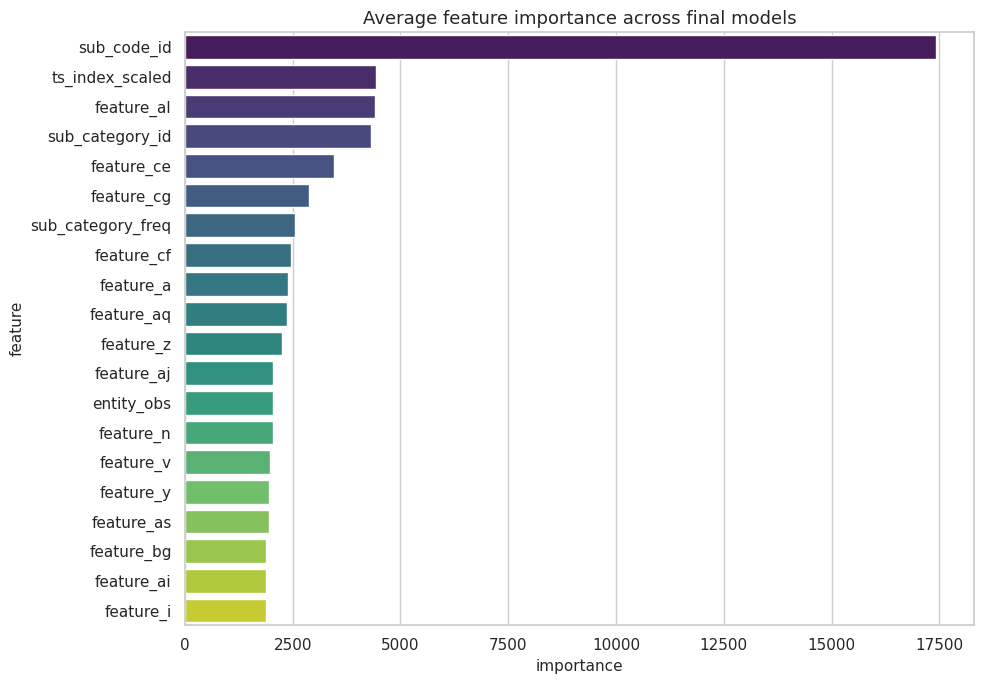

In [26]:
plt.figure(figsize=(10, 7))
sns.barplot(data=mean_importance, y="feature", x="importance", palette="viridis")
plt.title("Average feature importance across final models")
plt.tight_layout()
plt.show()

### Prediction distribution review

This plot compares the training target distribution with the final prediction distribution.

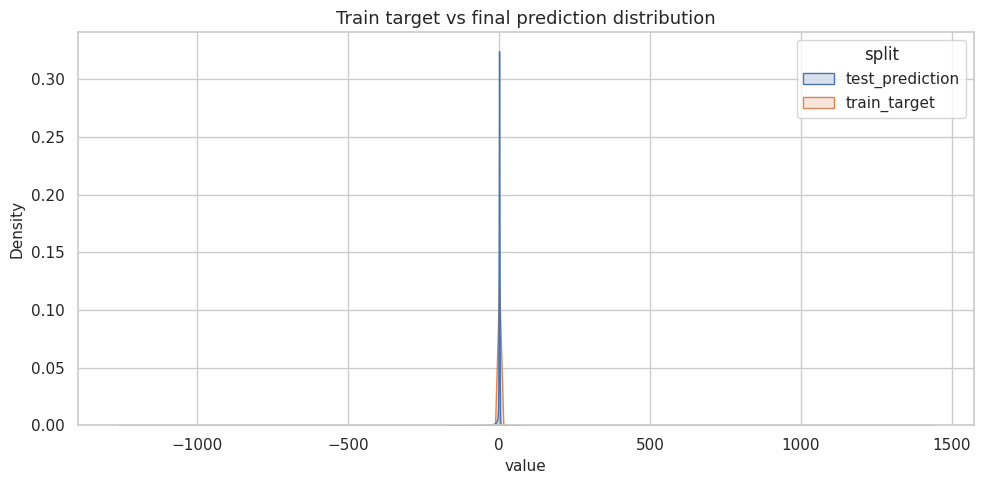

In [27]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=distribution_frame,
    x="value",
    hue="split",
    fill=True,
    common_norm=False,
    alpha=0.20,
)
plt.title("Train target vs final prediction distribution")
plt.tight_layout()
plt.show()

### Prediction summary by horizon

The table below summarizes the exported predictions for each horizon.

In [28]:
display(
    prediction_profile.groupby(CFG.horizon_col)["prediction"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

,horizon,mean,std,min,max
0,1,-0.294370,1.490425,-22.244074,7.756397
1,3,-0.628055,3.508374,-44.568939,23.396486
2,10,-1.819419,8.672464,-106.330940,51.946693
3,25,-3.221966,15.536742,-173.404297,86.440819


## 10. Analysis Summary

This notebook implements a strictly sequential prediction workflow for the Hedge Fund - Time Series Forecasting competition.

Workflow:
1. Environment setup: imports, plotting defaults, and reproducibility settings.
2. Metric and file discovery: competition score, memory helpers, and dataset path discovery.
3. EDA: distribution review, missingness review, and time-based plots.
4. Sequential features: row summaries, categorical encodings, and lag-based causal features.
5. Validation: rolling time splits, specialist horizon models, and blend selection using the competition metric.
6. Final fit: full-data training, horizon-aware prediction blending, and submission export.
7. Diagnostics: feature importance and prediction distribution checks.

---

### Citation

A data COMPANY. Hedge fund - Time series forecasting. https://kaggle.com/competitions/ts-forecasting, 2026. Kaggle.
